# Transition Operators

## Transition Operator - Gaussian Mixture 

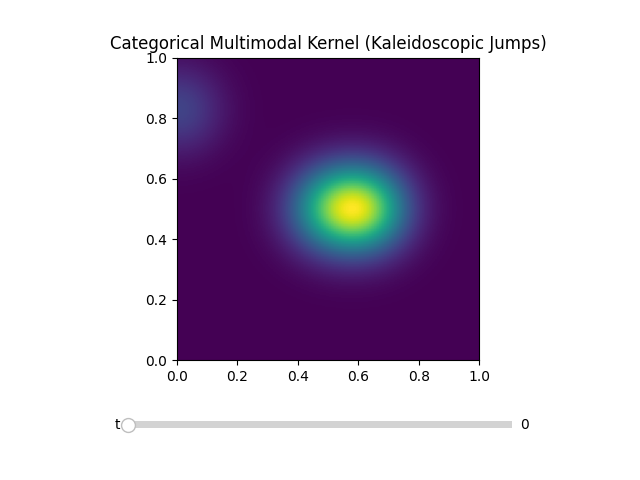

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from midi_utils import *

def cycle(arr_2D):
    def cycle_list(lst):
        while True:
            for item in lst:
                yield item

    def round_robin(gens):
        i = 0
        while True:
            yield next(gens[i])
            i = (i + 1) % len(gens)

    generators = [cycle_list(lst) for lst in arr_2D]
    return round_robin(generators)

# ----------------------------
# parameters
# ----------------------------
T = 50
GRID = 120

sigma_p = 0.1   # local spread inside a mode
sigma_d = 0.1

# ----------------------------
# trajectory (control signal)
# ----------------------------
z = np.zeros((T, 2))
z[0] = np.array([0.5, 0.5])

# ----------------------------
# grid (for visualization only)
# ----------------------------
grid = np.linspace(0, 1, GRID)
P, D = np.meshgrid(grid, grid)

# ----------------------------
# MODE DEFINITIONS (key change)
# ----------------------------
def get_modes(p, d):
    return [
        np.array([p + 0.25*d, d]),              # continuation
        np.array([1 - p, d]),                  # mirror pitch
        np.array([p, 1 - d]),                  # rhythm inversion
        np.array([d, p]),                      # diagonal swap
        np.array([(p + 0.5) % 1, (d + 0.33) % 1])  # distant echo
    ]

def get_weights():
    return np.array([0.7, 0.1, 0.3, 0.1, 0.2])

# ----------------------------
# KERNEL (for visualization only)
# ----------------------------
def transition_kernel(center):
    p, d = center
    K = np.zeros_like(P)

    mus = get_modes(p, d)
    weights = get_weights()

    for mu, w in zip(mus, weights):
        mp, md = mu

        E = (
            ((P - mp)**2) / (2 * sigma_p**2)
            + ((D - md)**2) / (2 * sigma_d**2)
        )

        K += w * np.exp(-E)

    K /= K.sum() + 1e-12
    return K

# ----------------------------
# CATEGORICAL SAMPLER (core change)
# ----------------------------
def sample_from_kernel(center):
    p, d = center

    mus = get_modes(p, d)
    weights = get_weights()
    weights = weights / weights.sum()

    # STEP 1: choose a mode (THIS creates jumpiness)
    k = np.random.choice(len(mus), p=weights)
    mu = mus[k]

    # STEP 2: local Gaussian around that mode
    p_new = np.random.normal(mu[0], sigma_p)
    d_new = np.random.normal(mu[1], sigma_d)

    return np.clip([p_new, d_new], 0, 1)

# ----------------------------
# generate trajectory
# ----------------------------
for t in range(T - 1):
    z[t + 1] = sample_from_kernel(z[t])

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

heat = ax.imshow(
    transition_kernel(z[0]),
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="viridis"
)

traj_line, = ax.plot([], [], lw=2, color="white")
pt, = ax.plot([], [], "ro")
pt_mean, = ax.plot([], [], "wo")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Categorical Multimodal Kernel (Kaleidoscopic Jumps)")

# ----------------------------
# slider
# ----------------------------
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])
slider = Slider(ax_slider, "t", 0, T-1, valinit=0, valstep=1)

def update(val):
    t = int(slider.val)

    traj_line.set_data(z[:t, 0], z[:t, 1])

    K = transition_kernel(z[t])
    heat.set_data(K)

    # red dot = actual sampled state
    pt.set_data([z[t, 0]], [z[t, 1]])

    # white dot = expectation (structure reference)
    K_norm = K / (K.sum() + 1e-12)
    p_mean = np.sum(K_norm * P)
    d_mean = np.sum(K_norm * D)

    pt_mean.set_data([p_mean], [d_mean])

    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()

In [3]:
PCS = [0,2,3,7,9,10]
tempo = 2
compression = 0.85


vels = cycle([[1,10],[15],[30],[10,10,40]])

#  Linearly shrinks values toward 0.5.
def compress(x, alpha=0.3):
    return 0.5 + alpha * (x - 0.5)

def convert_to_signal(seq):
    out = []
    total_time = 0
    for i in seq:
        pitch = int(i[0]*36) + 48
        dur = int(((i[1]*8) + 1)) * 0.125 
        dur = compress(dur,compression) * tempo
        out.append([harmonic_quantize(pitch, PCS), next(vels), dur, total_time])

        
        total_time += dur
    return out


mel = convert_to_signal(z)


# play_event_tuples(mel)

# Transition Operator - Time Dependent Kernel

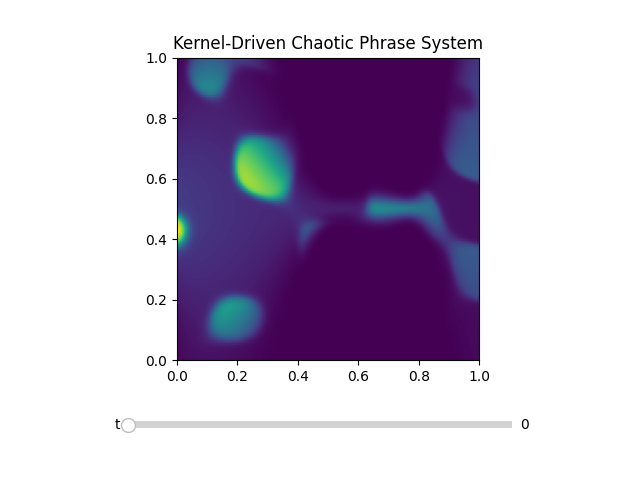

In [4]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ----------------------------
# parameters
# ----------------------------
T = 30 * 1
GRID = 120
collapse_period = 10

sigma_p = 0.1
sigma_d = 0.1

# ----------------------------
# grid
# ----------------------------
grid = np.linspace(0, 1, GRID)
P, D = np.meshgrid(grid, grid)

# ----------------------------
# phrase timing
# ----------------------------
def phrase_phase(t, period=10):
    return (t % period) / period

def collapse_strength(t, period=10):
    phase = phrase_phase(t, period)
    return np.exp(-((phase - 0.95)**2) / (2 * 0.02**2))

# ----------------------------
# kernel (NOW GENERATIVE)
# ----------------------------
def transition_kernel(center, t):
    p, d = center

    # ----------------------------
    # CHAOTIC FIELD
    # ----------------------------
    rp = np.sin(13.7 * p + 9.2 * d)
    rd = np.cos(17.3 * d - 11.1 * p)

    rp2 = np.sin(31.1 * p * d + 5.7)
    rd2 = np.cos(23.4 * (p - d))

    f1 = 2 + 5 * rp
    f2 = 3 + 6 * rd
    f3 = 4 + 7 * rp2
    f4 = 6 + 8 * rd2

    ph1 = 2 * np.pi * rp
    ph2 = 2 * np.pi * rd
    ph3 = 2 * np.pi * rp2
    ph4 = 2 * np.pi * rd2

    E = (
        np.sin(f1 * P + f2 * D + ph1) +
        np.cos(f3 * P - f4 * D + ph2) +
        np.sin((f2 + f4) * (P * D) + ph3) +
        np.cos(10 * (P - rp) * (D - rd) + ph4)
    )

    E = np.tanh(3.0 * E)

    # ----------------------------
    # RHYTHMIC GEOMETRY
    # ----------------------------
    stability = 0.5 * (1 + np.sin(6 * P + 3 * np.cos(4 * P)))

    sigma_min = 0.02
    sigma_max = 0.5

    sigma_field = sigma_min + (1 - stability) * (sigma_max - sigma_min)

    E_duration = -((D - d)**2) / (2 * sigma_field**2)

    # ----------------------------
    # CENTERING (prevents drift)
    # ----------------------------
    center_force = -1.5 * (P - 0.5)

    # ----------------------------
    # PHRASE COLLAPSE
    # ----------------------------
    c = collapse_strength(t, collapse_period)

    E_collapse_duration = -((D - 1)**2) / (2 * 0.02**2)
    E_collapse_pitch = -((P - 0.25)**2) / (2 * 0.08**2)

    E_collapse = E_collapse_duration + E_collapse_pitch

    # ----------------------------
    # COMBINE
    # ----------------------------
    E_base = E + E_duration + center_force
    E_total = (1 - c) * E_base + c * E_collapse

    K = np.exp(E_total)
    K /= K.sum() + 1e-12

    return K

# ----------------------------
# SAMPLING FROM KERNEL (KEY FIX)
# ----------------------------
def sample_from_kernel(center, t):
    K = transition_kernel(center, t)

    flat = K.ravel()
    idx = np.random.choice(len(flat), p=flat)

    i, j = np.unravel_index(idx, K.shape)

    return np.array([P[i, j], D[i, j]])

# ----------------------------
# trajectory
# ----------------------------
z = np.zeros((T, 2))
z[0] = np.array([0.5, 0.5])

for t in range(T - 1):
    z[t + 1] = sample_from_kernel(z[t], t)

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

heat = ax.imshow(
    transition_kernel(z[0], 0),
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="viridis"
)

traj_line, = ax.plot([], [], lw=2, color="white")
pt, = ax.plot([], [], "ro")
pt_mean, = ax.plot([], [], "wo")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Kernel-Driven Chaotic Phrase System")

# ----------------------------
# slider
# ----------------------------
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])
slider = Slider(ax_slider, "t", 0, T-1, valinit=0, valstep=1)

def update(val):
    t = int(slider.val)

    traj_line.set_data(z[:t, 0], z[:t, 1])

    K = transition_kernel(z[t], t)
    heat.set_data(K)

    pt.set_data([z[t, 0]], [z[t, 1]])

    # expectation marker
    K_norm = K / (K.sum() + 1e-12)
    p_mean = np.sum(K_norm * P)
    d_mean = np.sum(K_norm * D)
    pt_mean.set_data([p_mean], [d_mean])

    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()

In [5]:
PCS = [0,2,3,5,7,8,10]
tempo = 0.125
compression = 0.1


vels = cycle([[40,10],[15],[30],[10,10,40,10,20,10]])
# vels = cycle([[10,10,10,10,10,10,10,10,10,60]])

#  Linearly shrinks values toward 0.5.
def compress(x, alpha=0.3):
    return 0.5 + alpha * (x - 0.5)

def convert_to_signal(seq):
    out = []
    total_time = 0
    for i in seq:
        pitch = int(i[0]*36) + 48
        dur = int(((i[1]*16) + 1)) * tempo
        # dur = compress(dur,compression) * tempo
        out.append([harmonic_quantize(pitch, PCS), next(vels), dur, total_time])

        
        total_time += dur
    return out


mel = convert_to_signal(z)


# play_event_tuples(mel)

# Midi Scheduling

In [2]:
# Midi File Authoring 
from midi_utils import *
from IPython.display import FileLink

events = [
    (60, 100, 1, 0),  # C4
    (64, 100, 2, 1),  # E4 
    (67, 100, 1, 0),  # G4
]

events_to_midi(events, "./outputs/test.mid")
FileLink("./outputs/test.mid")

/Users/raul/Gray Area/AlgorithmicMusic-EventSynthesis/binder/notebooks/outputs/test.mid

In [4]:
# Injecting Audio!
from IPython.display import Javascript, display
from pathlib import Path
import json


js = Path("../audio/midi_audio.js").read_text()

# inject Javascript Audio Stuff
display(Javascript(js))

events = [
    (60, 100, 0.0, 1.0),
    (64, 100, 1.0, 1.0),
    (67, 100, 2.0, 1.0),
]


display(Javascript(f"window.midiAudio.playEvents({json.dumps(events)})"))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>